In [ ]:
!pip install statsmodels scikit-learn --quiet

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
from google.colab import files
import io

uploaded = files.upload()

df = pd.read_csv(io.BytesIO(uploaded['final_rb_analysis_master.csv']))
df.head()


Saving final_rb_analysis_master.csv to final_rb_analysis_master.csv


,Player,Team,Age,G,GS,rAtt,rYds,rTD,r1D,rLng,...,Unnamed: 10,inflated_value,inflated_apy,inflated_guaranteed,Season,Wins,Losses,WinPct,Team_RushYds,Team_PassYds
0,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,166310094.0,27718349.0,57307687.0,2001,3.0,9.0,0.25,1695.0,3685.0
1,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,40574797.0,13524931.0,17535122.0,2001,3.0,9.0,0.25,1695.0,3685.0
2,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,65238484.0,10873081.0,47634448.0,2001,3.0,9.0,0.25,1695.0,3685.0
3,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,11146357.0,5573178.0,5410853.0,2001,3.0,9.0,0.25,1695.0,3685.0
4,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,3073229.0,3073229.0,2609346.0,2001,3.0,9.0,0.25,1695.0,3685.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load your merged master dataset
df = pd.read_csv("final_rb_analysis_master.csv")

print("Shape:", df.shape)
df.head()


Shape: (5019, 34)


,Player,Team,Age,G,GS,rAtt,rYds,rTD,r1D,rLng,...,Unnamed: 10,inflated_value,inflated_apy,inflated_guaranteed,Season,Wins,Losses,WinPct,Team_RushYds,Team_PassYds
0,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,166310094.0,27718349.0,57307687.0,2001,3.0,9.0,0.25,1695.0,3685.0
1,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,40574797.0,13524931.0,17535122.0,2001,3.0,9.0,0.25,1695.0,3685.0
2,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,65238484.0,10873081.0,47634448.0,2001,3.0,9.0,0.25,1695.0,3685.0
3,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,11146357.0,5573178.0,5410853.0,2001,3.0,9.0,0.25,1695.0,3685.0
4,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,3073229.0,3073229.0,2609346.0,2001,3.0,9.0,0.25,1695.0,3685.0


In [ ]:
df.columns = df.columns.str.strip()

# Make sure core numeric fields are numeric
num_cols = [
    "Age", "G", "GS", "rAtt", "rYds", "rTD", "r1D", "rLng", "rY/A", "rY/g",
    "Fmb", "Season", "Wins", "Losses", "WinPct",
    "Team_RushYds", "Team_PassYds",
    "apy", "inflated_apy", "total_value", "inflated_value"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Use inflation-adjusted APY as main salary variable
if "inflated_apy" in df.columns:
    df["APY_Infl_Millions"] = df["inflated_apy"] / 1_000_000
else:
    # fallback: use non-adjusted APY, but this really shouldn't happen
    df["APY_Infl_Millions"] = df["apy"] / 1_000_000

# Create a working RB DataFrame with some light filtering
rb = df.copy()

# Filter to seasons with meaningful usage & salary info
rb = rb[
    (rb["rAtt"].notna()) &
    (rb["rAtt"] >= 70) &              # only real workload RB years
    rb["APY_Infl_Millions"].notna() &
    rb["Season"].notna()
].copy()

print("Filtered RB sample shape:", rb.shape)
rb[["Player", "Team", "Season", "rAtt", "rYds", "rTD", "rY/A", "APY_Infl_Millions"]].head()


Filtered RB sample shape: (5019, 35)


,Player,Team,Season,rAtt,rYds,rTD,rY/A,APY_Infl_Millions
0,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,27.718349
1,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,13.524931
2,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,10.873081
3,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,5.573178
4,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,3.073229


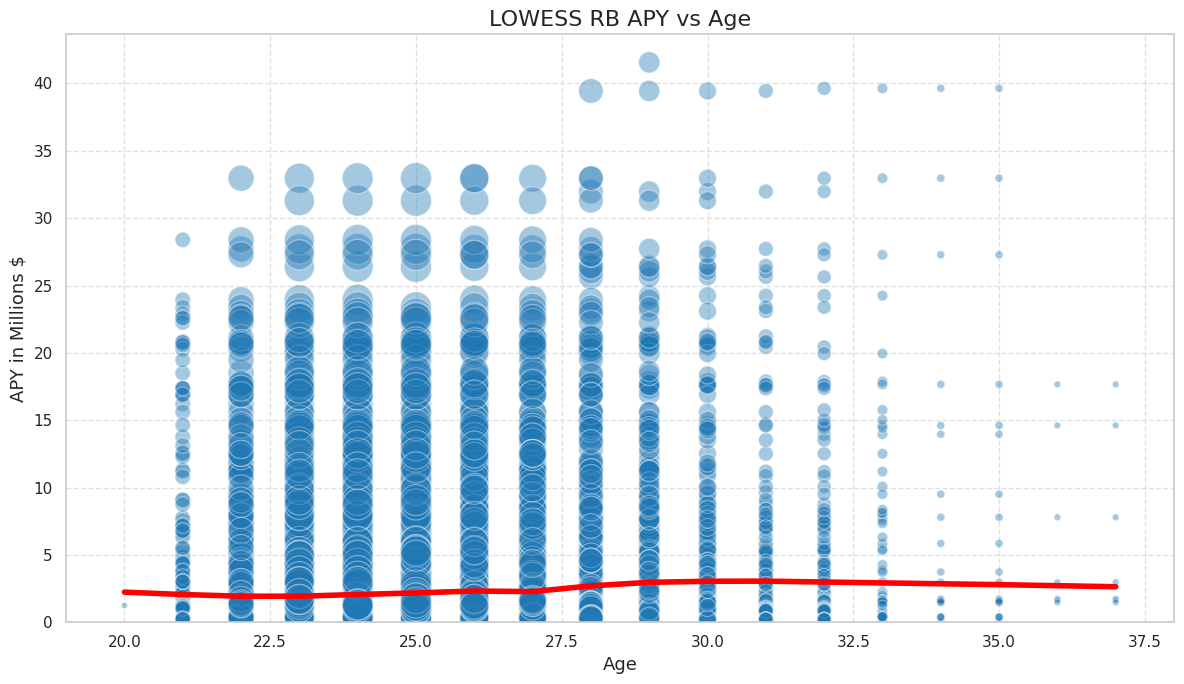

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# Load the data
rb = pd.read_csv("final_rb_analysis_master.csv")

# Ensure the APY_Infl_Millions column exists
rb['APY_Infl_Millions'] = rb['inflated_apy'] / 1_000_000

age_counts = rb.groupby('Age').size().reset_index(name='Player_Count')
rb = pd.merge(rb, age_counts, on='Age', how='left')

rb_sorted = rb.sort_values(by="Age")

# Calculate the LOWESS line data manually
lowess_data = sm.nonparametric.lowess(
    endog=rb_sorted["APY_Infl_Millions"],
    exog=rb_sorted["Age"],
    frac=0.3, # Low smoothing for clear peak/drop-off
    is_sorted=True
)
lowess_age = lowess_data[:, 0]
lowess_apy = lowess_data[:, 1]

fig, ax = plt.subplots(figsize=(12,7))

ax.plot(lowess_age, lowess_apy, color="red", linewidth=4, label="LOWESS Trend (Smoothed APY)")

sns.scatterplot(
    data=rb,
    x="Age", y="APY_Infl_Millions",
    size="Player_Count",
    sizes=(20, 500),
    alpha=0.4,
    color='tab:blue',
    legend=False,
    ax=ax
)

sns.regplot(
    data=rb,
    x="Age", y="APY_Infl_Millions",
    lowess=True,
    scatter=False,
    line_kws={'alpha': 0},
    ci=95,
    ax=ax
)


ax.set_title("LOWESS RB APY vs Age", fontsize=16)
ax.set_xlabel("Age", fontsize=13)
ax.set_ylabel("APY in Millions $", fontsize=13)
ax.set_xlim(19, 38)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

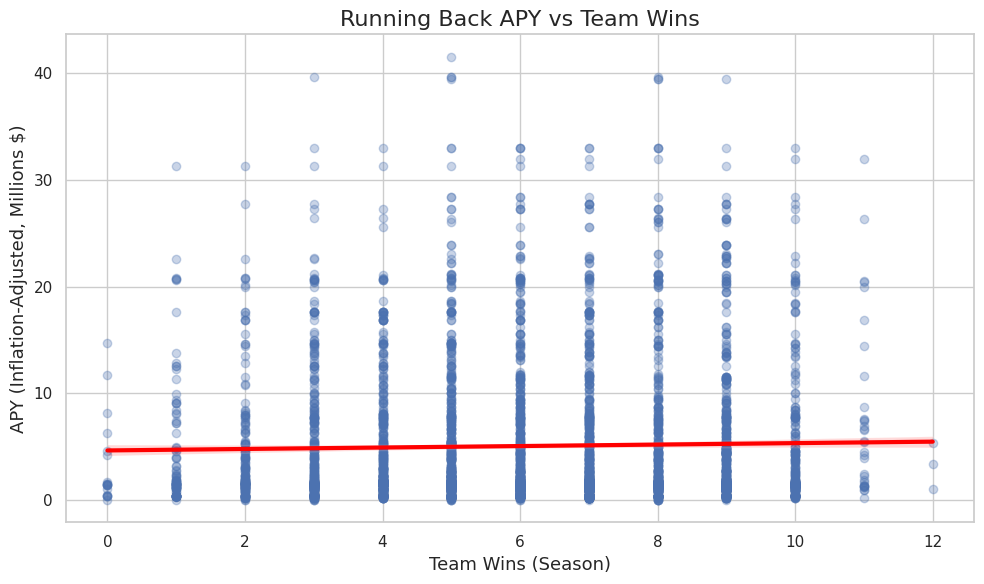

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=rb,
    x="Wins", y="APY_Infl_Millions",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red", "linewidth": 3}
)
plt.title("Running Back APY vs Team Wins", fontsize=16)
plt.xlabel("Team Wins (Season)", fontsize=13)
plt.ylabel("APY (Inflation-Adjusted, Millions $)", fontsize=13)
plt.tight_layout()
plt.show()


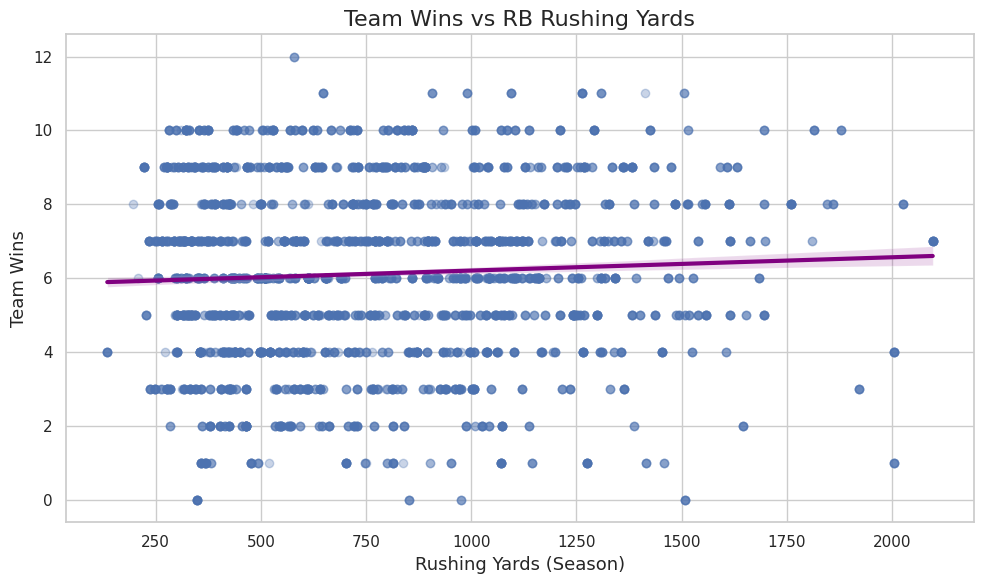

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=rb,
    x="rYds", y="Wins",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "purple", "linewidth": 3}
)
plt.title("Team Wins vs RB Rushing Yards", fontsize=16)
plt.xlabel("Rushing Yards (Season)", fontsize=13)
plt.ylabel("Team Wins", fontsize=13)
plt.tight_layout()
plt.show()


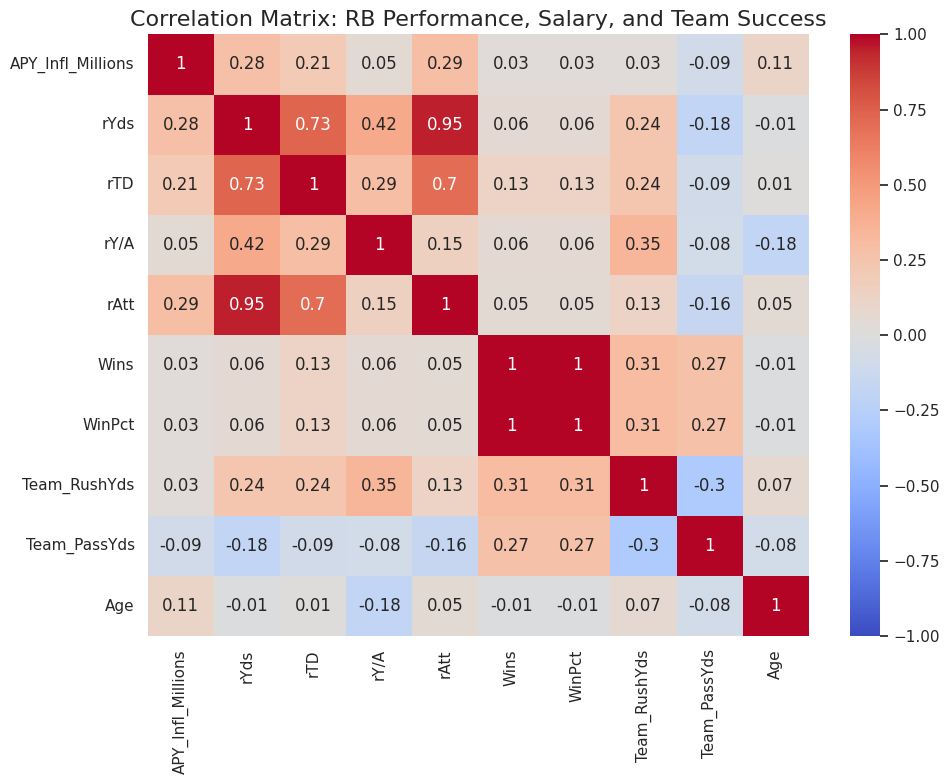

In [ ]:
corr_cols = [
    "APY_Infl_Millions",
    "rYds", "rTD", "rY/A", "rAtt",
    "Wins", "WinPct", "Team_RushYds", "Team_PassYds", "Age"
]

corr_df = rb[corr_cols].dropna()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_df.corr().round(2),
    annot=True, cmap="coolwarm", vmin=-1, vmax=1
)
plt.title("Correlation Matrix: RB Performance, Salary, and Team Success", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
import json
import pandas as pd
import glob

# Path where your JSONs are stored
files = sorted(glob.glob("espn_team_stats_*.json"))

all_rows = []

for f in files:
    season = int(f.split("_")[-1].split(".")[0])  # extract season year

    with open(f, "r") as infile:
        data = json.load(infile)

        for team in data:
            wins = team.get("record", {}).get("wins")
            losses = team.get("record", {}).get("losses")
            stats = team.get("stats", {})

            pass_yards = stats.get("offense_passing_yards")
            rush_yards = stats.get("offense_rushing_yards")

            all_rows.append({
                "Season": season,
                "Team": team["abbrev"],
                "Wins": wins,
                "Losses": losses,
                "PassYds": pass_yards,
                "RushYds": rush_yards
            })

espn_df = pd.DataFrame(all_rows)
espn_df.head()

,Season,Team,Wins,Losses,PassYds,RushYds
0,2000,ARI,2.0,10.0,3478.0,1278.0
1,2000,ATL,3.0,9.0,3166.0,1214.0
2,2000,BAL,10.0,3.0,3102.0,2199.0
3,2000,BUF,6.0,6.0,3936.0,1922.0
4,2000,CAR,5.0,7.0,3850.0,1186.0


In [ ]:
espn_df = espn_df.dropna(subset=["Wins", "PassYds"])
espn_df["Wins"] = espn_df["Wins"].astype(int)
espn_df["PassYds"] = espn_df["PassYds"].astype(float)

print("Dataset shape:", espn_df.shape)
espn_df.head()


Dataset shape: (797, 6)


,Season,Team,Wins,Losses,PassYds,RushYds
0,2000,ARI,2,10.0,3478.0,1278.0
1,2000,ATL,3,9.0,3166.0,1214.0
2,2000,BAL,10,3.0,3102.0,2199.0
3,2000,BUF,6,6.0,3936.0,1922.0
4,2000,CAR,5,7.0,3850.0,1186.0


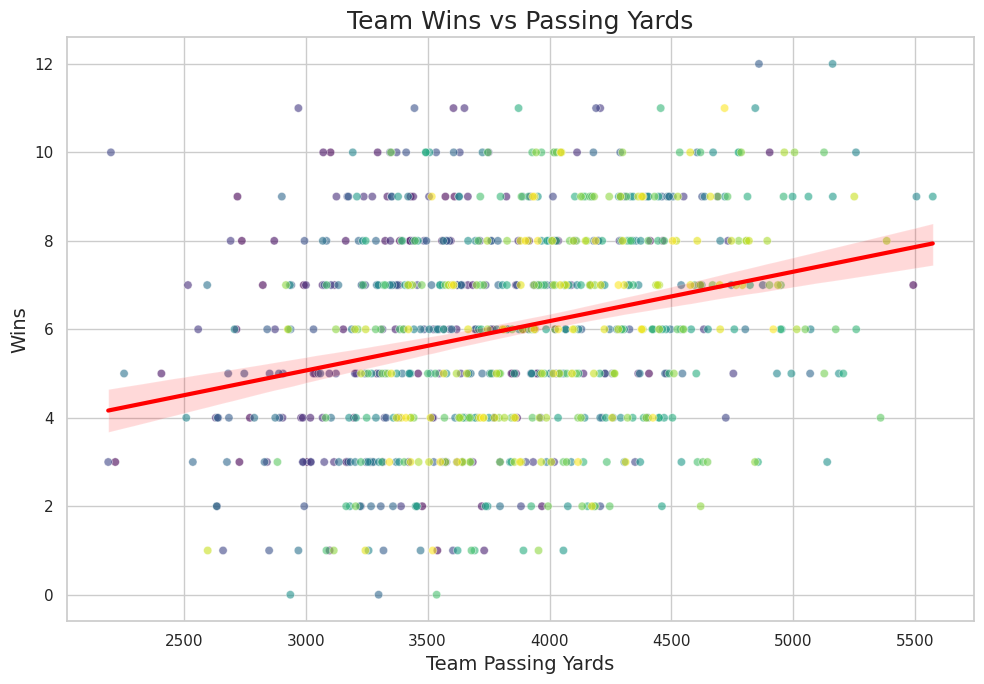

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=espn_df,
    x="PassYds",
    y="Wins",
    hue="Season",
    palette="viridis",
    alpha=0.6,
    legend=False
)

sns.regplot(
    data=espn_df,
    x="PassYds",
    y="Wins",
    scatter=False,
    color="red",
    line_kws={"linewidth": 3}
)

plt.title("Team Wins vs Passing Yards", fontsize=18)
plt.xlabel("Team Passing Yards", fontsize=14)
plt.ylabel("Wins", fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import statsmodels.api as sm

# Load & basic cleaning
rb = pd.read_csv("final_rb_analysis_master.csv")
rb.columns = rb.columns.str.strip()

# numeric conversions
for col in ["rYds", "rTD", "rY/A", "Fmb", "Wins", "Age", "inflated_apy"]:
    if col in rb.columns:
        rb[col] = pd.to_numeric(rb[col], errors="coerce")

# main salary variable
rb["APY_Infl_Millions"] = rb["inflated_apy"] / 1_000_000

# keep only seasons with real data
reg_cols = ["APY_Infl_Millions", "rYds", "rTD", "rY/A", "Fmb", "Wins", "Age"]
reg_df = rb[reg_cols].dropna()

print("Rows in regression:", reg_df.shape[0])

X = reg_df[["rYds", "rTD", "rY/A", "Fmb", "Wins", "Age"]]
y = reg_df["APY_Infl_Millions"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


Rows in regression: 4251
                            OLS Regression Results                            
Dep. Variable:      APY_Infl_Millions   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     73.01
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           5.87e-87
Time:                        07:32:58   Log-Likelihood:                -13751.
No. Observations:                4251   AIC:                         2.752e+04
Df Residuals:                    4244   BIC:                         2.756e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8521      

In [ ]:
# reuse dataframe from above
rb["Season"] = pd.to_numeric(rb["Season"], errors="coerce")

ts_df = rb[
    ["Season", "rAtt", "rYds", "rTD", "rY/A", "APY_Infl_Millions"]
].dropna()

season_summary = ts_df.groupby("Season").agg(
    avg_rAtt=("rAtt", "mean"),
    avg_rYds=("rYds", "mean"),
    avg_rTD=("rTD", "mean"),
    avg_y_per_carry=("rY/A", "mean"),
    avg_apy_infl=("APY_Infl_Millions", "mean")
).reset_index()

season_summary.head()


,Season,avg_rAtt,avg_rYds,avg_rTD,avg_y_per_carry,avg_apy_infl
0,2001,262.709091,1134.909091,6.872727,4.345455,12.214001
1,2002,284.654545,1245.836364,11.854545,4.352727,12.068597
2,2003,274.566667,1166.200000,10.850000,4.163333,11.810851
3,2004,255.926471,1071.573529,9.735294,4.144118,11.364585
4,2005,211.246914,920.061728,7.481481,4.309877,8.945849


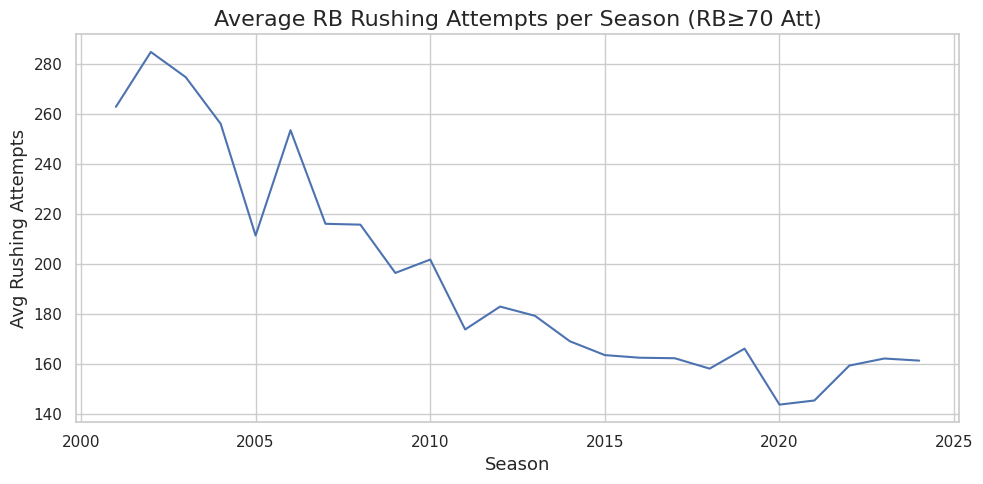

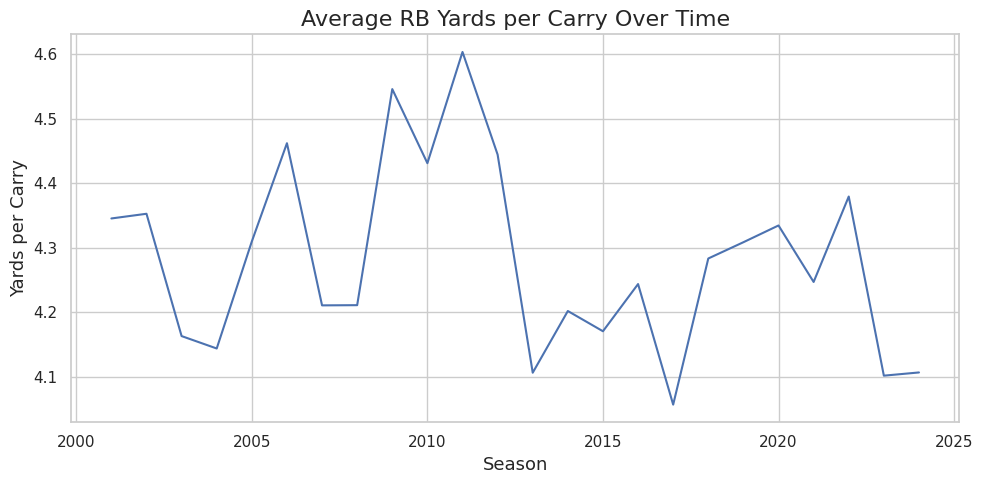

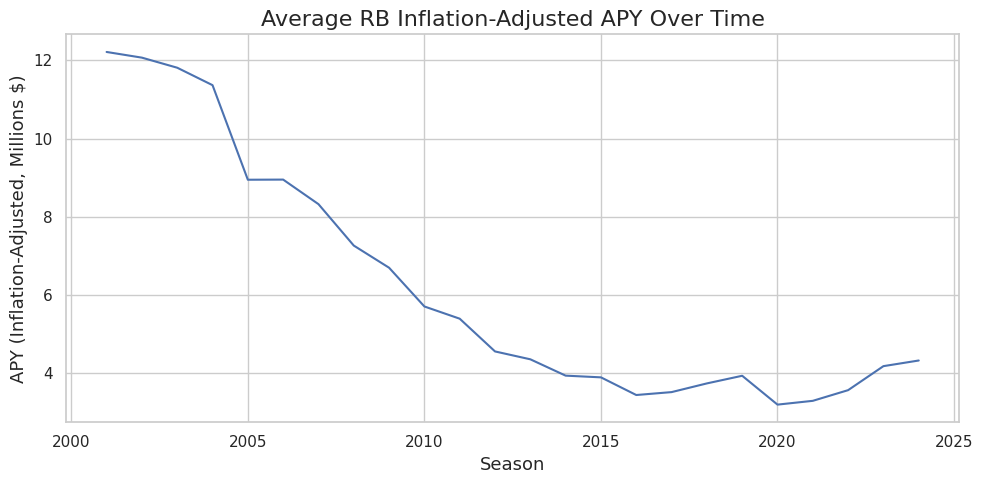

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# RB workload over time
plt.figure(figsize=(10,5))
plt.plot(season_summary["Season"], season_summary["avg_rAtt"])
plt.title("Average RB Rushing Attempts per Season (RB≥70 Att)", fontsize=16)
plt.xlabel("Season", fontsize=13)
plt.ylabel("Avg Rushing Attempts", fontsize=13)
plt.tight_layout()
plt.show()

# RB efficiency over time
plt.figure(figsize=(10,5))
plt.plot(season_summary["Season"], season_summary["avg_y_per_carry"])
plt.title("Average RB Yards per Carry Over Time", fontsize=16)
plt.xlabel("Season", fontsize=13)
plt.ylabel("Yards per Carry", fontsize=13)
plt.tight_layout()
plt.show()

# RB pay over time
plt.figure(figsize=(10,5))
plt.plot(season_summary["Season"], season_summary["avg_apy_infl"])
plt.title("Average RB Inflation-Adjusted APY Over Time", fontsize=16)
plt.xlabel("Season", fontsize=13)
plt.ylabel("APY (Inflation-Adjusted, Millions $)", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Only keep rows with team rushing data
team_df = rb.copy()
team_df = team_df.dropna(subset=["rYds", "Team_RushYds", "Wins", "APY_Infl_Millions"])

team_df["RB_RushShare"] = team_df["rYds"] / team_df["Team_RushYds"]

team_df[["Player", "Team", "Season", "rYds", "Team_RushYds", "RB_RushShare"]].head()



,Player,Team,Season,rYds,Team_RushYds,RB_RushShare
0,LaDainian Tomlinson,LAC,2001,1236,1695.0,0.729204
1,LaDainian Tomlinson,LAC,2001,1236,1695.0,0.729204
2,LaDainian Tomlinson,LAC,2001,1236,1695.0,0.729204
3,LaDainian Tomlinson,LAC,2001,1236,1695.0,0.729204
4,LaDainian Tomlinson,LAC,2001,1236,1695.0,0.729204


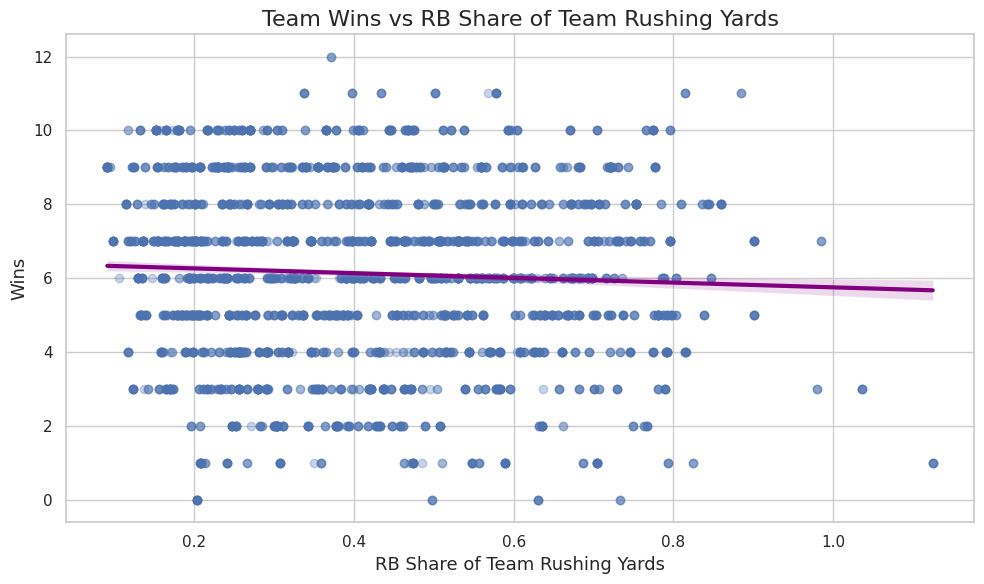

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=team_df,
    x="RB_RushShare",
    y="Wins",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "purple", "linewidth": 3}
)
plt.title("Team Wins vs RB Share of Team Rushing Yards", fontsize=16)
plt.xlabel("RB Share of Team Rushing Yards", fontsize=13)
plt.ylabel("Wins", fontsize=13)
plt.tight_layout()
plt.show()


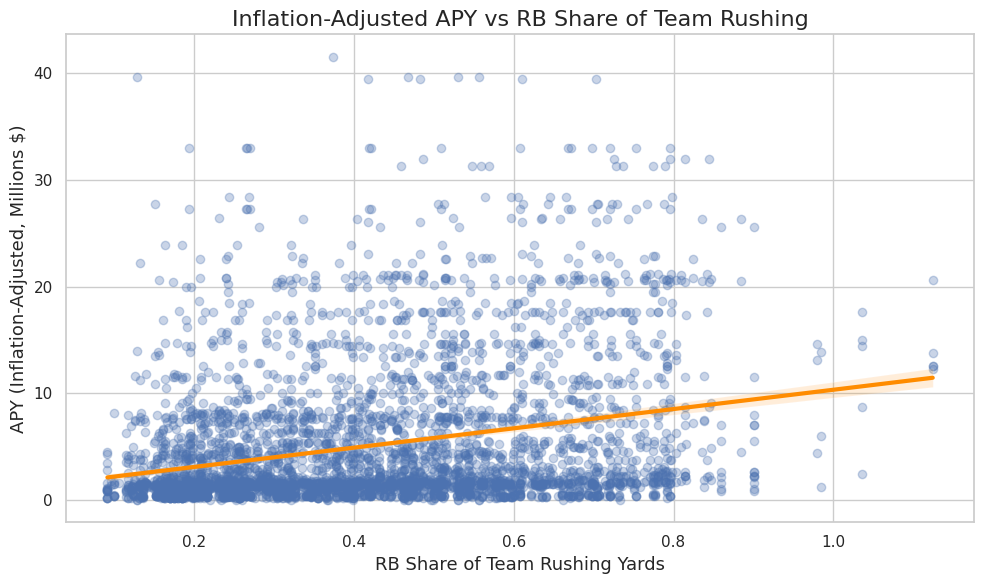

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=team_df,
    x="RB_RushShare",
    y="APY_Infl_Millions",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "darkorange", "linewidth": 3}
)
plt.title("Inflation-Adjusted APY vs RB Share of Team Rushing", fontsize=16)
plt.xlabel("RB Share of Team Rushing Yards", fontsize=13)
plt.ylabel("APY (Inflation-Adjusted, Millions $)", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("final_rb_analysis_master.csv")

# Keep only numeric fields we need
df = df[[
    "inflated_apy",   # salary (dependent variable)
    "rYds", "rTD", "rY/A", "Fmb", "rAtt",
    "Wins", "Age"
]].dropna()

df.head()


Saving final_rb_analysis_master.csv to final_rb_analysis_master (1).csv


,inflated_apy,rYds,rTD,rY/A,Fmb,rAtt,Wins,Age
0,27718349.0,1236,10,3.6,8,339,3.0,22
1,13524931.0,1236,10,3.6,8,339,3.0,22
2,10873081.0,1236,10,3.6,8,339,3.0,22
3,5573178.0,1236,10,3.6,8,339,3.0,22
4,3073229.0,1236,10,3.6,8,339,3.0,22


In [ ]:
from sklearn.preprocessing import StandardScaler

X_cols = ["rYds", "rTD", "rY/A", "Fmb", "rAtt", "Wins", "Age"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[X_cols])
df_scaled = pd.DataFrame(X_scaled, columns=X_cols)

y = df["inflated_apy"]


In [ ]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("final_rb_analysis_master.csv")
df.columns = df.columns.str.strip()

# Make sure numeric
for c in ["rYds", "rTD", "rY/A", "Fmb", "Wins", "inflated_apy"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# inflation-adjusted APY in millions
df["APY_Infl_Millions"] = df["inflated_apy"] / 1_000_000

# Feature set for the model
features = ["rYds", "rTD", "rY/A", "Fmb", "Wins"]

# Build modeling dataframe and drop any missing rows
model_df = df[["APY_Infl_Millions"] + features].dropna().reset_index(drop=True)

print("Modeling dataframe shape:", model_df.shape)
model_df.head()


Modeling dataframe shape: (4251, 6)


,APY_Infl_Millions,rYds,rTD,rY/A,Fmb,Wins
0,27.718349,1236,10,3.6,8,3.0
1,13.524931,1236,10,3.6,8,3.0
2,10.873081,1236,10,3.6,8,3.0
3,5.573178,1236,10,3.6,8,3.0
4,3.073229,1236,10,3.6,8,3.0


In [ ]:
# Separate X and y
X = model_df[features].copy()
y = model_df["APY_Infl_Millions"].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit OLS
X_sm = sm.add_constant(X_scaled)
model = sm.OLS(y, X_sm).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      APY_Infl_Millions   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     76.62
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           4.02e-77
Time:                        07:54:12   Log-Likelihood:                -13777.
No. Observations:                4251   AIC:                         2.757e+04
Df Residuals:                    4245   BIC:                         2.760e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0719      0.095     53.443      0.0

In [ ]:
# Extract coefficients and confidence intervals (skip the intercept at index 0)
params = model.params[1:]
conf = model.conf_int().iloc[1:]   # skip const row

coef_df = pd.DataFrame({
    "feature": features,
    "coef": params.values,
    "ci_lower": conf[0].values,
    "ci_upper": conf[1].values
})

# Sort by absolute size of coefficient for nicer plotting
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=True)

coef_df


,feature,coef,ci_lower,ci_upper,abs_coef
1,rTD,-0.003069,-0.280793,0.274656,0.003069
3,Fmb,0.045202,-0.168980,0.259383,0.045202
4,Wins,0.078910,-0.109618,0.267437,0.078910
2,rY/A,-0.486532,-0.692784,-0.280281,0.486532
0,rYds,1.979996,1.663021,2.296971,1.979996


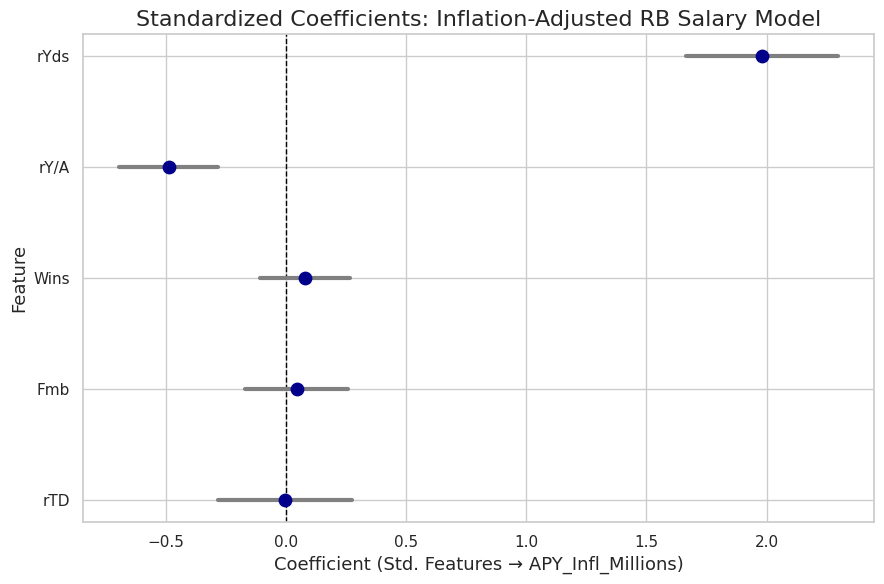

In [ ]:
plt.figure(figsize=(9,6))

# Horizontal line at 0
plt.axvline(0, color="black", linewidth=1, linestyle="--")

# Error bars (95% CI)
for i, row in coef_df.iterrows():
    plt.plot(
        [row["ci_lower"], row["ci_upper"]],
        [row["feature"], row["feature"]],
        color="gray",
        linewidth=3
    )

# Point estimates
plt.scatter(coef_df["coef"], coef_df["feature"], s=80, color="darkblue", zorder=3)

plt.title("Standardized Coefficients: Inflation-Adjusted RB Salary Model", fontsize=16)
plt.xlabel("Coefficient (Std. Features → APY_Infl_Millions)", fontsize=13)
plt.ylabel("Feature", fontsize=13)
plt.tight_layout()
plt.show()


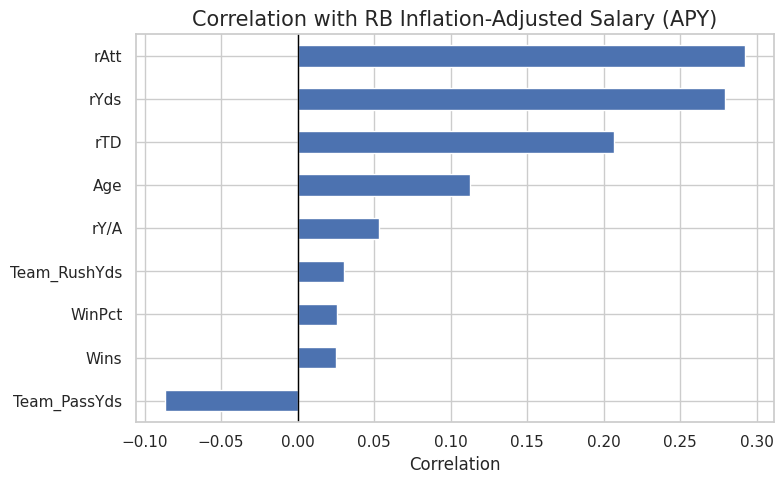

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Use the same columns you used for the heatmap
corr = corr_df.corr()["APY_Infl_Millions"].drop("APY_Infl_Millions")

plt.figure(figsize=(8,5))
corr.sort_values().plot(kind="barh")
plt.title("Correlation with RB Inflation-Adjusted Salary (APY)", fontsize=15)
plt.xlabel("Correlation", fontsize=12)
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()


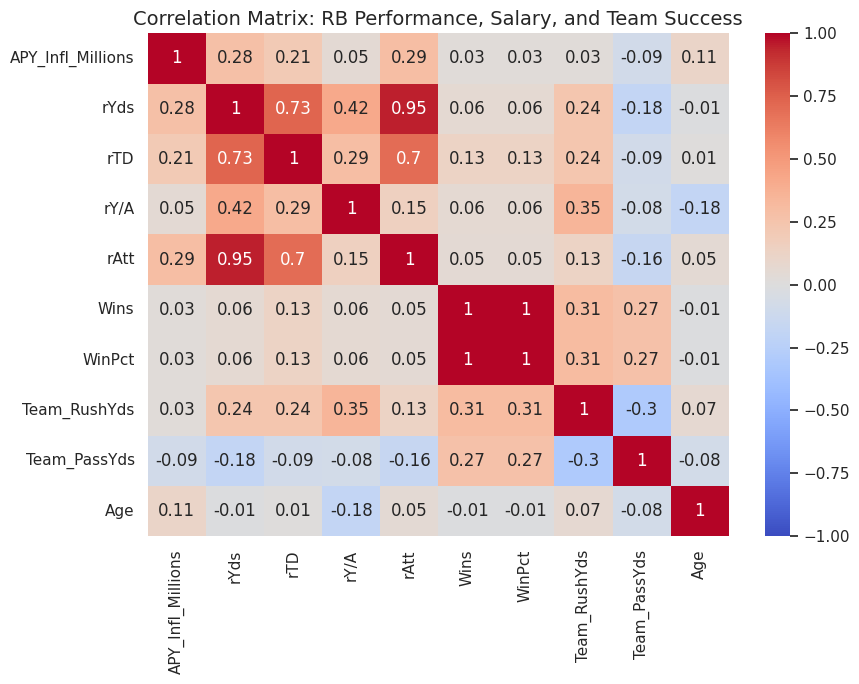

In [ ]:
# Select variables to include
corr_cols = [
    "APY_Infl_Millions",
    "rYds", "rTD", "rY/A", "rAtt",
    "Wins", "WinPct",
    "Team_RushYds", "Team_PassYds",
    "Age"
]

corr_df = rb[corr_cols].dropna()
corr_matrix = corr_df.corr().round(2)

fig, ax = plt.subplots(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    ax=ax
)

ax.set_title("Correlation Matrix: RB Performance, Salary, and Team Success", fontsize=14)
plt.tight_layout()
plt.show()


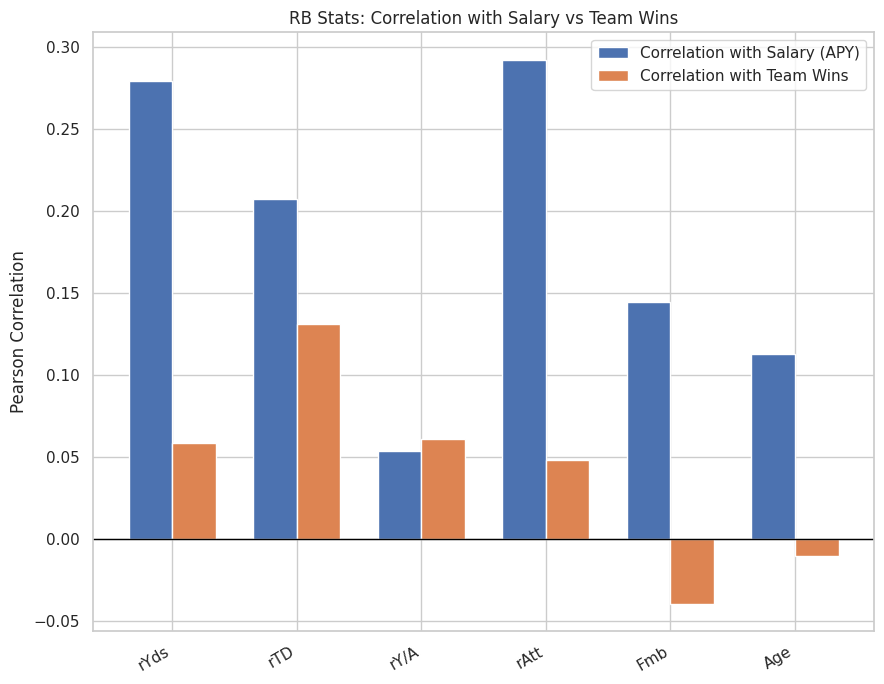

In [ ]:
metrics = ["rYds", "rTD", "rY/A", "rAtt", "Fmb", "Age"]
target_salary = "APY_Infl_Millions"
target_wins = "Wins"

sub = rb[[target_salary, target_wins] + [m for m in metrics if m in rb.columns]].dropna()

corr_to_salary = [sub[m].corr(sub[target_salary]) for m in metrics]
corr_to_wins   = [sub[m].corr(sub[target_wins])   for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9,7))

bars1 = ax.bar(x - width/2, corr_to_salary, width, label="Correlation with Salary (APY)", color="#4C72B0")
bars2 = ax.bar(x + width/2, corr_to_wins,   width, label="Correlation with Team Wins",   color="#DD8452")

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=30, ha="right")
ax.set_ylabel("Pearson Correlation")
ax.set_title("RB Stats: Correlation with Salary vs Team Wins")
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
df.columns.tolist()


['Player',
 'Team',
 'Age',
 'G',
 'GS',
 'rAtt',
 'rYds',
 'rTD',
 'r1D',
 'rLng',
 'rY/A',
 'rY/g',
 'Fmb',
 'Year',
 'player',
 'team',
 'year_signed',
 'years',
 'Unnamed: 4',
 'total_value',
 'apy',
 'guaranteed',
 'Unnamed: 8',
 'apy_cap_pct',
 'Unnamed: 10',
 'inflated_value',
 'inflated_apy',
 'inflated_guaranteed',
 'Season',
 'Wins',
 'Losses',
 'WinPct',
 'Team_RushYds',
 'Team_PassYds']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df = pd.read_csv("final_rb_analysis_master.csv")

features = [
    "rYds",
    "rTD",
    "rY/A",
    "rAtt",
    "inflated_apy"
]

rb_cluster = df[features].dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(rb_cluster)

k = 4   # 4 value tiers
kmeans = KMeans(n_clusters=k, random_state=42)
rb_cluster["Cluster"] = kmeans.fit_predict(scaled)

df_clusters = pd.concat([df.loc[rb_cluster.index, ["Player","Team","Season"]].reset_index(drop=True),
                         rb_cluster.reset_index(drop=True)], axis=1)

df_clusters.head()


,Player,Team,Season,rYds,rTD,rY/A,rAtt,inflated_apy,Cluster
0,LaDainian Tomlinson,LAC,2001,1236,10,3.6,339,27718349.0,2
1,LaDainian Tomlinson,LAC,2001,1236,10,3.6,339,13524931.0,2
2,LaDainian Tomlinson,LAC,2001,1236,10,3.6,339,10873081.0,1
3,LaDainian Tomlinson,LAC,2001,1236,10,3.6,339,5573178.0,1
4,LaDainian Tomlinson,LAC,2001,1236,10,3.6,339,3073229.0,1


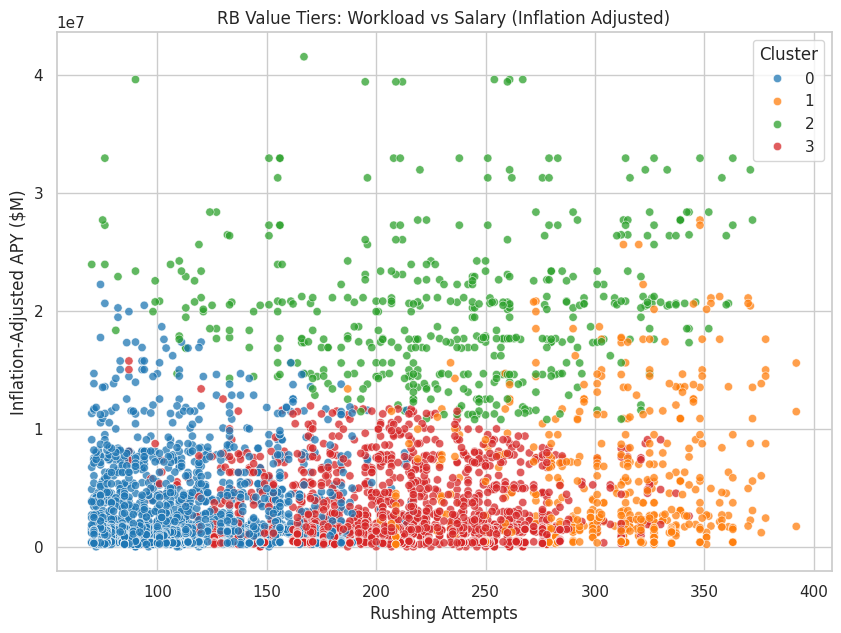

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_clusters,
    x="rAtt",
    y="inflated_apy",
    hue="Cluster",
    palette="tab10",
    alpha=0.75
)

plt.title("RB Value Tiers: Workload vs Salary (Inflation Adjusted)")
plt.xlabel("Rushing Attempts")
plt.ylabel("Inflation-Adjusted APY ($M)")
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rb_cluster = df[["Player", "Team", "Season",
                 "rAtt", "rYds", "rTD", "rY/A",
                 "inflated_apy"]].dropna().copy()

rb_cluster["APY_Infl_Millions"] = rb_cluster["inflated_apy"] / 1e6

# Features that define "value tier"
features = ["rAtt", "rYds", "rTD", "rY/A", "APY_Infl_Millions"]

scaler = StandardScaler()
X = scaler.fit_transform(rb_cluster[features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
rb_cluster["Cluster"] = kmeans.fit_predict(X)

rb_cluster.head()


,Player,Team,Season,rAtt,rYds,rTD,rY/A,inflated_apy,APY_Infl_Millions,Cluster
0,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,27718349.0,27.718349,3
1,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,13524931.0,13.524931,3
2,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,10873081.0,10.873081,1
3,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,5573178.0,5.573178,1
4,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,3073229.0,3.073229,1


In [ ]:
import pandas as pd
import glob, json

# Load main merged CSV
df = pd.read_csv("final_rb_analysis_master.csv")
df.columns = df.columns.str.strip()  # clean

print("Main DF columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()


Main DF columns: ['Player', 'Team', 'Age', 'G', 'GS', 'rAtt', 'rYds', 'rTD', 'r1D', 'rLng', 'rY/A', 'rY/g', 'Fmb', 'Year', 'player', 'team', 'year_signed', 'years', 'Unnamed: 4', 'total_value', 'apy', 'guaranteed', 'Unnamed: 8', 'apy_cap_pct', 'Unnamed: 10', 'inflated_value', 'inflated_apy', 'inflated_guaranteed', 'Season', 'Wins', 'Losses', 'WinPct', 'Team_RushYds', 'Team_PassYds']
Shape: (5019, 34)


,Player,Team,Age,G,GS,rAtt,rYds,rTD,r1D,rLng,...,Unnamed: 10,inflated_value,inflated_apy,inflated_guaranteed,Season,Wins,Losses,WinPct,Team_RushYds,Team_PassYds
0,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,166310094.0,27718349.0,57307687.0,2001,3.0,9.0,0.25,1695.0,3685.0
1,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,40574797.0,13524931.0,17535122.0,2001,3.0,9.0,0.25,1695.0,3685.0
2,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,65238484.0,10873081.0,47634448.0,2001,3.0,9.0,0.25,1695.0,3685.0
3,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,11146357.0,5573178.0,5410853.0,2001,3.0,9.0,0.25,1695.0,3685.0
4,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,NaN,3073229.0,3073229.0,2609346.0,2001,3.0,9.0,0.25,1695.0,3685.0


In [ ]:
all_rows = []

files = sorted(glob.glob("espn_team_stats_*.json"))

for f in files:
    season = int(f.split("_")[-1].split(".")[0])  # extract year
    with open(f, "r") as infile:
        data = json.load(infile)

        for team in data:
            team_abbr = team.get("abbrev")
            rec = team.get("record", {}) or {}
            wins = rec.get("wins")
            losses = rec.get("losses")

            stats = team.get("stats", {}) or {}
            rush_yards = stats.get("offense_rushing_yards")
            pass_yards = stats.get("offense_passing_yards")

            all_rows.append({
                "Season": season,
                "Team": team_abbr,
                "Wins": wins,
                "Losses": losses,
                "Team_RushYds_espn": rush_yards,
                "Team_PassYds_espn": pass_yards,
            })

espn_df = pd.DataFrame(all_rows)
espn_df.head(), espn_df.shape


(   Season Team  Wins  Losses  Team_RushYds_espn  Team_PassYds_espn
 0    2000  ARI   2.0    10.0             1278.0             3478.0
 1    2000  ATL   3.0     9.0             1214.0             3166.0
 2    2000  BAL  10.0     3.0             2199.0             3102.0
 3    2000  BUF   6.0     6.0             1922.0             3936.0
 4    2000  CAR   5.0     7.0             1186.0             3850.0,
 (800, 6))

In [ ]:
df["Season"] = pd.to_numeric(df["Season"], errors="coerce")
espn_df["Season"] = pd.to_numeric(espn_df["Season"], errors="coerce")

espn_merge = espn_df[["Season", "Team", "Wins", "Losses", "Team_RushYds_espn", "Team_PassYds_espn"]]

for col in ["Wins", "Losses"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

final_df = df.merge(
    espn_merge,
    how="left",
    left_on=["Season", "Team"],
    right_on=["Season", "Team"]
)

print("final_df shape:", final_df.shape)
final_df[["Player", "Team", "Season", "Wins", "Losses"]].head()


final_df shape: (5019, 36)


,Player,Team,Season,Wins,Losses
0,LaDainian Tomlinson,LAC,2001,3.0,9.0
1,LaDainian Tomlinson,LAC,2001,3.0,9.0
2,LaDainian Tomlinson,LAC,2001,3.0,9.0
3,LaDainian Tomlinson,LAC,2001,3.0,9.0
4,LaDainian Tomlinson,LAC,2001,3.0,9.0


In [ ]:
# Use inflation-adjusted APY as salary in millions
final_df["APY_Infl_Millions"] = pd.to_numeric(final_df["inflated_apy"], errors="coerce") / 1_000_000

# Filter to real RB seasons (70+ attempts, have salary & wins)
rb_cluster = final_df[
    (final_df["rAtt"].notna()) &
    (final_df["rAtt"] >= 70) &
    final_df["APY_Infl_Millions"].notna() &
    final_df["Wins"].notna()
].copy()

print("rb_cluster shape:", rb_cluster.shape)
rb_cluster[["Player", "Team", "Season", "rAtt", "rYds", "rTD", "rY/A", "APY_Infl_Millions", "Wins"]].head()


rb_cluster shape: (4251, 37)


,Player,Team,Season,rAtt,rYds,rTD,rY/A,APY_Infl_Millions,Wins
0,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,27.718349,3.0
1,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,13.524931,3.0
2,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,10.873081,3.0
3,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,5.573178,3.0
4,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,3.073229,3.0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["rYds", "rTD", "rY/A", "rAtt", "APY_Infl_Millions", "Wins"]

cluster_data = rb_cluster[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

rb_cluster = rb_cluster.loc[cluster_data.index].copy()
rb_cluster["Cluster"] = cluster_labels

rb_cluster[["Player", "Team", "Season", "Cluster"]].head()


,Player,Team,Season,Cluster
0,LaDainian Tomlinson,LAC,2001,2
1,LaDainian Tomlinson,LAC,2001,2
2,LaDainian Tomlinson,LAC,2001,2
3,LaDainian Tomlinson,LAC,2001,0
4,LaDainian Tomlinson,LAC,2001,0


In [ ]:
cluster_stats = rb_cluster.groupby("Cluster")[[
    "rAtt", "rYds", "rTD", "rY/A", "APY_Infl_Millions", "Wins"
]].mean().round(2)

cluster_counts = rb_cluster["Cluster"].value_counts().sort_index()

cluster_stats, cluster_counts


(           rAtt     rYds    rTD  rY/A  APY_Infl_Millions  Wins
 Cluster                                                       
 0        229.25  1022.31   7.66  4.51               3.57  6.39
 1        136.90   536.39   3.26  3.94               4.20  3.77
 2        296.82  1371.23  12.04  4.61              14.05  6.61
 3        111.46   468.11   2.94  4.23               3.40  7.77,
 Cluster
 0    1306
 1    1131
 2     562
 3    1252
 Name: count, dtype: int64)

In [ ]:
rb_cluster.groupby("Cluster")[["rAtt","rYds","rTD","rY/A","APY_Infl_Millions","Wins"]]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

sns.set(style="whitegrid")

df = pd.read_csv("final_rb_analysis_master.csv")

df.columns = df.columns.str.strip()

df["APY_Infl_Millions"] = pd.to_numeric(df["inflated_apy"], errors="coerce") / 1_000_000

feature_cols = ["rYds", "rTD", "rY/A", "rAtt", "Age", "Wins"]

model_df = df[["APY_Infl_Millions"] + feature_cols].dropna().copy()

print("Modeling sample shape:", model_df.shape)
model_df.head()


Modeling sample shape: (4251, 7)


,APY_Infl_Millions,rYds,rTD,rY/A,rAtt,Age,Wins
0,27.718349,1236,10,3.6,339,22,3.0
1,13.524931,1236,10,3.6,339,22,3.0
2,10.873081,1236,10,3.6,339,22,3.0
3,5.573178,1236,10,3.6,339,22,3.0
4,3.073229,1236,10,3.6,339,22,3.0


In [ ]:
X = model_df[feature_cols]
y = model_df["APY_Infl_Millions"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=model_df.index)
X_sm = sm.add_constant(X_scaled_df)

model = sm.OLS(y, X_sm).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      APY_Infl_Millions   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     75.22
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           1.55e-89
Time:                        08:47:13   Log-Likelihood:                -13745.
No. Observations:                4251   AIC:                         2.750e+04
Df Residuals:                    4244   BIC:                         2.755e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0719      0.094     53.830      0.0

/tmp/ipython-input-227992511.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


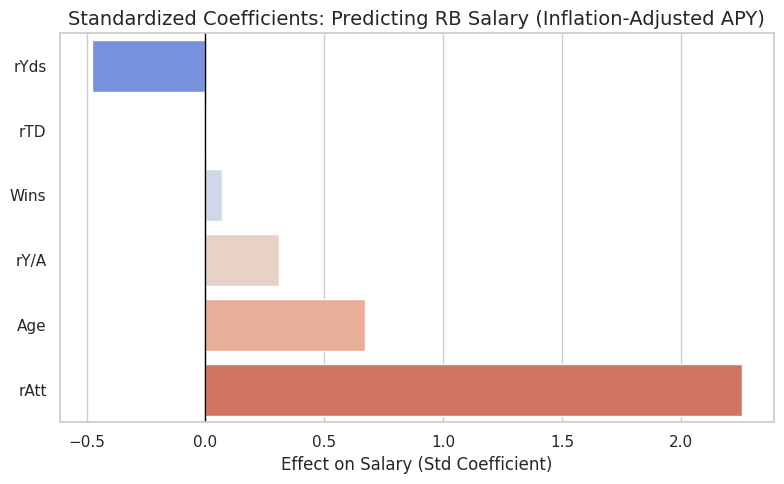

,Feature,Coefficient
0,rYds,-0.476206
1,rTD,0.002358
5,Wins,0.070010
2,rY/A,0.311071
4,Age,0.672534
3,rAtt,2.254984


In [ ]:
coefs = model.params.drop("const")
coef_df = pd.DataFrame({
    "Feature": coefs.index,
    "Coefficient": coefs.values
}).sort_values("Coefficient")

plt.figure(figsize=(8,5))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature",
    palette="coolwarm"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Standardized Coefficients: Predicting RB Salary (Inflation-Adjusted APY)", fontsize=14)
plt.xlabel("Effect on Salary (Std Coefficient)", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

coef_df


In [ ]:
model_df["Pred_APY_Infl_Millions"] = model.predict(X_sm)

# Residual = actual - predicted
model_df["Residual_APY"] = model_df["APY_Infl_Millions"] - model_df["Pred_APY_Infl_Millions"]

q_low = model_df["Residual_APY"].quantile(0.33)
q_high = model_df["Residual_APY"].quantile(0.67)

print("Residual thresholds:")
print("  Low  (Underpaid)  <=", q_low)
print("  High (Overpaid)   >=", q_high)

def label_value_tier(resid):
    if resid <= q_low:
        return "Underpaid Value"
    elif resid >= q_high:
        return "Overpaid / Risky"
    else:
        return "Fairly Paid"

model_df["ValueTier"] = model_df["Residual_APY"].apply(label_value_tier)

model_df["ValueTier"].value_counts()


Residual thresholds:
  Low  (Underpaid)  <= -2.9786278032868223
  High (Overpaid)   >= -0.2119995036944875


,count
ValueTier,
Fairly Paid,1445
Overpaid / Risky,1403
Underpaid Value,1403


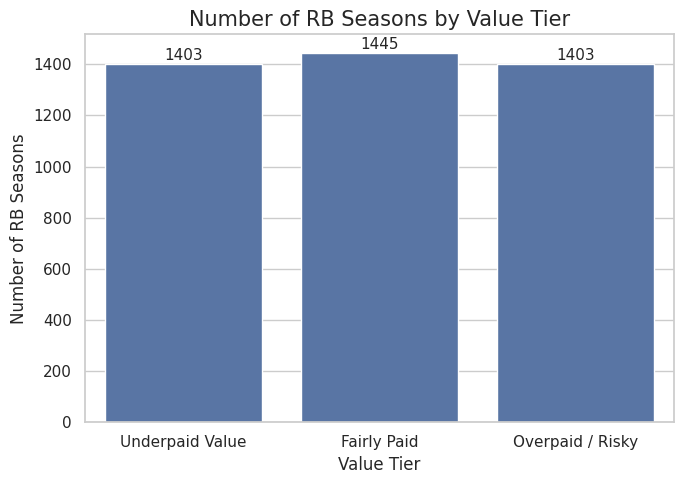

In [ ]:
plt.figure(figsize=(7,5))
order = ["Underpaid Value", "Fairly Paid", "Overpaid / Risky"]

sns.countplot(
    data=model_df,
    x="ValueTier",
    order=order
)
plt.title("Number of RB Seasons by Value Tier", fontsize=15)
plt.xlabel("Value Tier", fontsize=12)
plt.ylabel("Number of RB Seasons", fontsize=12)

counts = model_df["ValueTier"].value_counts()
for i, tier in enumerate(order):
    n = counts.get(tier, 0)
    plt.text(i, n + 2, str(n), ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()


/tmp/ipython-input-3880582290.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipython-input-3880582290.py:5: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.boxplot(


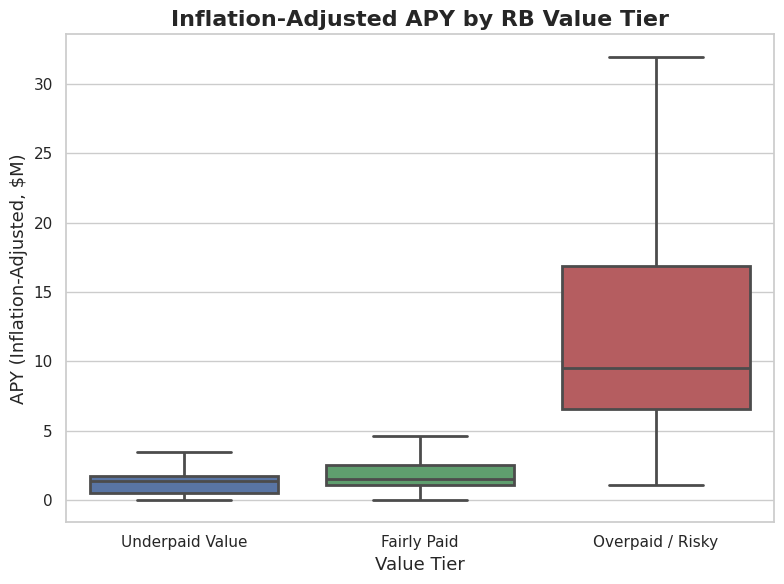

In [ ]:
counts = model_df["ValueTier"].value_counts().reindex(order)

plt.figure(figsize=(8,6))
ax = sns.boxplot(
    data=model_df,
    x="ValueTier",
    y="APY_Infl_Millions",
    order=order,
    showfliers=False,
    linewidth=2,
    palette=tier_colors
)

plt.title("Inflation-Adjusted APY by RB Value Tier", fontsize=16, weight="bold")
plt.xlabel("Value Tier", fontsize=13)
plt.ylabel("APY (Inflation-Adjusted, $M)", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
cluster_stats = model_df.groupby("ValueTier")[[
    "APY_Infl_Millions","rAtt","rYds","rTD","rY/A","Wins"
]].mean().round(2)

cluster_counts = model_df["ValueTier"].value_counts()

cluster_stats, cluster_counts


(                  APY_Infl_Millions    rAtt    rYds   rTD  rY/A  Wins
 ValueTier                                                            
 Fairly Paid                    2.04  131.07  552.44  3.84  4.20  6.01
 Overpaid / Risky              11.88  185.49  808.58  6.00  4.31  6.14
 Underpaid Value                1.39  221.64  973.47  7.25  4.36  6.24,
 ValueTier
 Fairly Paid         1445
 Overpaid / Risky    1403
 Underpaid Value     1403
 Name: count, dtype: int64)

In [ ]:
import pandas as pd

df = pd.read_csv("final_rb_analysis_master.csv")

df["Season"] = pd.to_numeric(df["Season"], errors="coerce")
df["year_signed"] = pd.to_numeric(df["year_signed"], errors="coerce")

df["APY_Infl_Millions"] = df["inflated_apy"] / 1_000_000

df.head()


,Player,Team,Age,G,GS,rAtt,rYds,rTD,r1D,rLng,...,inflated_value,inflated_apy,inflated_guaranteed,Season,Wins,Losses,WinPct,Team_RushYds,Team_PassYds,APY_Infl_Millions
0,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,166310094.0,27718349.0,57307687.0,2001,3.0,9.0,0.25,1695.0,3685.0,27.718349
1,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,40574797.0,13524931.0,17535122.0,2001,3.0,9.0,0.25,1695.0,3685.0,13.524931
2,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,65238484.0,10873081.0,47634448.0,2001,3.0,9.0,0.25,1695.0,3685.0,10.873081
3,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,11146357.0,5573178.0,5410853.0,2001,3.0,9.0,0.25,1695.0,3685.0,5.573178
4,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,3073229.0,3073229.0,2609346.0,2001,3.0,9.0,0.25,1695.0,3685.0,3.073229


In [ ]:
contract_years = df[
    df["year_signed"].notna() & (df["Season"] == df["year_signed"])
].copy()

contract_years.shape


(479, 35)

In [ ]:
next_stats = df[[
    "Player", "Team", "Season",
    "rAtt", "rYds", "rTD", "rY/A", "Wins", "APY_Infl_Millions"
]].copy()

next_stats = next_stats.rename(columns={
    "Team": "Team_next",
    "Season": "Season_next",
    "rAtt": "rAtt_next",
    "rYds": "rYds_next",
    "rTD": "rTD_next",
    "rY/A": "rYA_next",
    "Wins": "Wins_next",
    "APY_Infl_Millions": "APY_Infl_Millions_next"
})

next_stats["Season_contract"] = next_stats["Season_next"] - 1

next_stats.head()


,Player,Team_next,Season_next,rAtt_next,rYds_next,rTD_next,rYA_next,Wins_next,APY_Infl_Millions_next,Season_contract
0,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,3.0,27.718349,2000
1,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,3.0,13.524931,2000
2,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,3.0,10.873081,2000
3,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,3.0,5.573178,2000
4,LaDainian Tomlinson,LAC,2001,339,1236,10,3.6,3.0,3.073229,2000


In [ ]:
merged = contract_years.merge(
    next_stats,
    left_on=["Player", "Season"],
    right_on=["Player", "Season_contract"],
    how="left",
    suffixes=("_contract", "_drop")
)

merged.shape
merged.head()


,Player,Team,Age,G,GS,rAtt,rYds,rTD,r1D,rLng,...,APY_Infl_Millions,Team_next,Season_next,rAtt_next,rYds_next,rTD_next,rYA_next,Wins_next,APY_Infl_Millions_next,Season_contract
0,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,10.873081,LAC,2002.0,372.0,1683.0,14.0,4.5,6.0,27.718349,2001.0
1,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,10.873081,LAC,2002.0,372.0,1683.0,14.0,4.5,6.0,13.524931,2001.0
2,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,10.873081,LAC,2002.0,372.0,1683.0,14.0,4.5,6.0,10.873081,2001.0
3,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,10.873081,LAC,2002.0,372.0,1683.0,14.0,4.5,6.0,5.573178,2001.0
4,LaDainian Tomlinson,LAC,22,16,16,339,1236,10,68,54,...,10.873081,LAC,2002.0,372.0,1683.0,14.0,4.5,6.0,3.073229,2001.0


In [ ]:
# Keep only rows where we *have* next-season data
post = merged.dropna(subset=["rYds_next", "rAtt_next", "Wins_next"]).copy()

post["delta_rYds"] = post["rYds_next"] - post["rYds"]
post["delta_rAtt"] = post["rAtt_next"] - post["rAtt"]
post["delta_Wins"] = post["Wins_next"] - post["Wins"]

post[["delta_rYds", "delta_rAtt", "delta_Wins"]].describe()


,delta_rYds,delta_rAtt,delta_Wins
count,1345.000000,1345.000000,1343.000000
mean,-8.191822,-1.653532,-0.146687
std,445.668748,86.171853,2.811794
min,-1090.000000,-237.000000,-8.000000
25%,-303.000000,-57.000000,-2.000000
50%,-28.000000,-3.000000,0.000000
75%,268.000000,50.000000,2.000000
max,1383.000000,305.000000,9.000000


In [ ]:
share_big_drop = (post["delta_rYds"] <= -100).mean()
share_big_jump = (post["delta_rYds"] >= 100).mean()

share_big_drop, share_big_jump


(np.float64(0.44535315985130114), np.float64(0.37397769516728624))

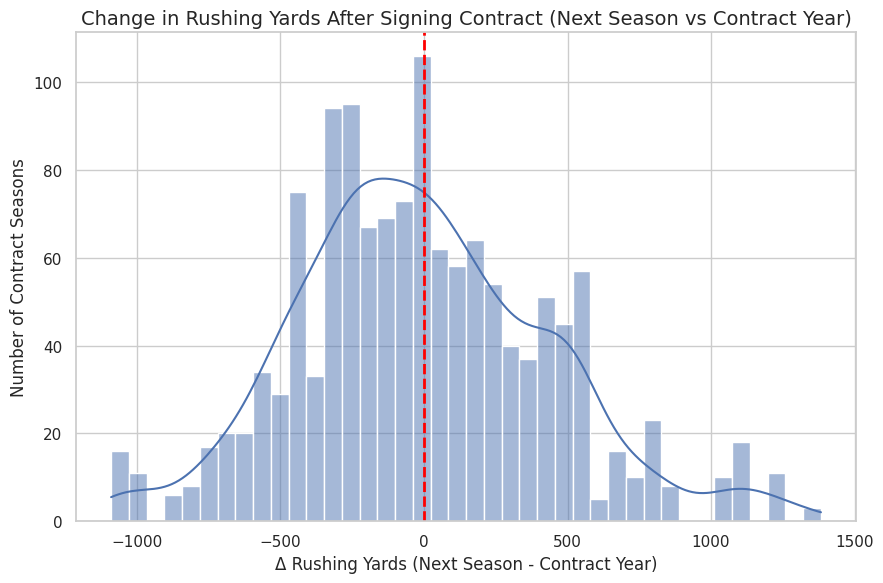

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(9,6))
sns.histplot(post["delta_rYds"], bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.title("Change in Rushing Yards After Signing Contract (Next Season vs Contract Year)", fontsize=14)
plt.xlabel("Δ Rushing Yards (Next Season - Contract Year)", fontsize=12)
plt.ylabel("Number of Contract Seasons", fontsize=12)
plt.tight_layout()
plt.show()
